<h1 style="text-align: center; color: Seagreen; text-transform: uppercase;">
   food delivery time prediction
</h1>

<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
   Technical Approach
</h2>

<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
   Problem Understanding
</h2

<h3 style="text-align: start; color:red; text-transform: uppercase;">
    Business Problem
</h3>

<h3 style="text-align: start; color:red; text-transform: uppercase;">
    Project Objective
</h3>

<h3 style="text-align: start; color:red; text-transform: uppercase;">
   Importance of Delivery Time Prediction
</h3>

<h3 style="text-align: start; color:red; text-transform: uppercase;">
    Machine Learning Problem Type
</h3>

<h3 style="text-align: start; color:red; text-transform: uppercase;">
    Target Variable
</h3>

<h3 style="text-align: start; color:red; text-transform: uppercase;">
    Input Features
</h3>

<h3 style="text-align: start; color:red; text-transform: uppercase;">
   Business Impact
</h3>

<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
   Feature Descriptions
</h2>

<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
   Data collection
</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
sns.set_style("darkgrid")
import warnings
import reverse_geocoder as rg
warnings.filterwarnings('ignore')
warnings.warn('this will not show')

In [2]:
data = pd.read_csv(r"C:\Users\babus\Data_Spark\Machine Learning\Data_collections\Project\Zomato Dataset.csv")
# data = pd.read_csv(r""C:\Users\babus\Data_Spark\Project\Zomato\Deployment\data\Zomato Dataset.csv"")

In [3]:
data.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [4]:
data.tail()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
45579,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35,11:45,Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32
45580,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55,20:10,Windy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36
45581,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50,24:05:00,Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16
45582,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35,13:40,Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26
45583,0x5fb2,RANCHIRES09DEL02,23.0,4.9,23.351058,85.325731,23.431058,85.405731,02-03-2022,17:10,17:15,Fog,Medium,2,Snack,scooter,1.0,No,Metropolitian,36


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

In [6]:
data.shape

(45584, 20)

In [7]:
data.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='object')

In [8]:
num_columns = data.select_dtypes(exclude='object').columns
num_columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Vehicle_condition',
       'multiple_deliveries', 'Time_taken (min)'],
      dtype='object')

In [9]:
obj_columns = data.select_dtypes(include='object').columns
obj_columns

Index(['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Type_of_order', 'Type_of_vehicle', 'Festival', 'City'],
      dtype='object')


<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
   Data Cleaning
</h2>

In [10]:
data.isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken (min)                  0
dtype: int64

### Checking Duplicate

In [11]:
data.duplicated().sum()

np.int64(0)

### Checking Data Types

In [12]:
for col in data:
    print(f"----------{col}-----------")
    
    print(data[col].unique(),'\n')

----------ID-----------
['0xcdcd' '0xd987' '0x2784' ... '0x4f8d' '0x5eee' '0x5fb2'] 

----------Delivery_person_ID-----------
['DEHRES17DEL01' 'KOCRES16DEL01' 'PUNERES13DEL03' ... 'KOCRES04DEL01'
 'BHPRES06DEL03' 'GOARES03DEL03'] 

----------Delivery_person_Age-----------
[36. 21. 23. 34. 24. 29. 35. 33. 25. 31. 37. 27. 32. 26. 38. 20. 22. nan
 28. 39. 30. 15. 50.] 

----------Delivery_person_Ratings-----------
[4.2 4.7 4.3 4.5 4.  4.9 4.1 5.  4.8 3.5 4.6 nan 4.4 3.8 3.9 3.7 2.6 2.5
 3.6 3.1 2.7 1.  3.2 3.3 6.  3.4 2.8 2.9 3. ] 

----------Restaurant_latitude-----------
[ 30.327968  10.003064  18.56245   30.899584  26.463504  19.176269
  12.311072  18.592718  17.426228  22.552672  18.563934  23.357804
  11.003669  12.986047  19.221315  13.005801  26.849596  21.160522
  12.934179  18.51421   11.022477  21.160437  15.51315   15.561295
   0.        18.55144   18.593481  21.173343  17.451976  12.972532
  13.064181  19.121999  21.149569  19.091458  22.539129  12.970324
  21.175975  23.36974

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

<h3 style="text-align: start; color: wheat;">
   Order_Date
</h3>

In [14]:
data['Order_Date'] = pd.to_datetime( data['Order_Date'] ,dayfirst=True )


<h3 style="text-align: start; color: wheat;">
   Time_Orderd
</h3>

In [15]:
in_correct_time = data[~data['Time_Orderd'].astype(str).str.contains(':', na=False)]

in_correct_time['Time_Orderd'].unique()

array(['0.458333333', '0.958333333', nan, '0.791666667', '0.875', '1',
       '0.375', '0.625', '0.833333333', '0.666666667', '0.75',
       '0.416666667', '0.916666667', '0.5', '0.708333333', '0.541666667',
       '0.583333333'], dtype=object)

In [16]:
error_Time_Orderd = (
    ~data['Time_Orderd'].astype(str).str.contains(':', na=False)
    ) & (data['Time_Orderd'].notna())

converted_hours = (
    pd.to_numeric(data.loc[error_Time_Orderd, 'Time_Orderd']) * 24
).round().astype(int)

In [17]:
data.loc[error_Time_Orderd, 'Time_Orderd'] = (
    converted_hours.astype(str).str.zfill(2) + ':00'
)

In [18]:
data['Time_Orderd'] = data['Time_Orderd'].str.replace(r'^24:','00:',regex=True )
data['Time_Orderd'] = data['Time_Orderd'].str.slice(0,5)

In [19]:
data['Time_Orderd'].unique()

array(['21:55', '14:55', '17:30', '09:20', '19:50', '20:25', '20:30',
       '20:40', '21:15', '20:20', '22:30', '08:15', '19:30', '12:25',
       '18:35', '20:35', '23:20', '21:20', '23:35', '22:35', '23:25',
       '13:35', '21:35', '18:55', '14:15', '11:00', '09:45', '08:40',
       '23:00', '17:25', nan, '19:45', '19:10', '10:55', '21:40', '19:00',
       '16:45', '11:30', '15:10', '22:45', '22:10', '20:45', '22:50',
       '17:55', '09:25', '20:15', '22:25', '22:40', '23:50', '15:25',
       '10:20', '20:55', '10:40', '15:55', '20:10', '12:10', '15:30',
       '10:35', '21:10', '20:50', '12:35', '21:00', '23:40', '18:15',
       '18:20', '11:45', '12:45', '23:30', '10:50', '21:25', '10:10',
       '17:50', '22:20', '12:40', '23:55', '10:25', '08:45', '23:45',
       '19:55', '22:15', '23:10', '09:15', '18:25', '18:45', '16:50',
       '00:00', '14:20', '10:15', '08:50', '09:00', '17:45', '16:35',
       '08:30', '21:45', '19:40', '14:50', '18:10', '12:20', '12:50',
       '09:10',

<h3 style="text-align: start; color: wheat;">
   Time_Order_picked
</h3>

In [20]:
in_correct_time_1 = data[~data['Time_Order_picked'].astype(str).str.contains(':', na=False)]

in_correct_time_1['Time_Order_picked'].unique()

array(['0.458333333', '0.75', '0.958333333', '0.916666667', '0.875',
       '0.375', '0.833333333', '0.708333333', '0.625', '1', '0.791666667',
       '0.5', '0.541666667', '0.416666667', '0.583333333', '0.666666667'],
      dtype=object)

In [21]:
error_Time_Order_picked = (
        ~ data['Time_Order_picked'].astype(str).str.contains(':',na=False)
        ) & ( data['Time_Order_picked'].notna() )

convert_hours =  (pd.to_numeric(data.loc[error_Time_Order_picked,'Time_Order_picked']) * 24
                 ).round().astype(int)

In [22]:
data.loc[error_Time_Order_picked, 'Time_Order_picked'] = (
    convert_hours.astype(str).str.zfill(2) + ':00'
)

In [23]:
data['Time_Order_picked'] = data['Time_Order_picked'].str.replace(r'^24:','00:',regex=True )
data['Time_Order_picked'] = data['Time_Order_picked'].str.slice(0,5)

In [24]:
data['Time_Order_picked'].unique()

array(['22:10', '15:05', '17:40', '09:30', '20:05', '20:35', '15:10',
       '20:40', '20:50', '21:30', '20:25', '22:45', '08:30', '19:45',
       '12:30', '18:50', '23:30', '21:35', '23:45', '22:50', '22:40',
       '23:35', '13:40', '21:45', '19:10', '14:25', '11:10', '09:55',
       '08:55', '23:10', '17:30', '18:35', '19:50', '19:25', '11:00',
       '19:15', '16:55', '11:40', '15:15', '22:55', '22:25', '20:55',
       '23:05', '18:00', '23:00', '09:40', '20:20', '22:35', '22:00',
       '23:55', '15:40', '10:30', '21:00', '10:50', '16:05', '20:15',
       '12:15', '15:45', '22:15', '10:45', '15:30', '00:05', '21:25',
       '12:45', '21:15', '18:20', '18:25', '11:50', '12:50', '10:55',
       '21:40', '10:20', '17:55', '23:50', '12:55', '00:10', '10:40',
       '09:00', '20:45', '20:00', '23:15', '22:20', '21:05', '17:00',
       '00:15', '21:20', '14:35', '10:25', '09:05', '16:50', '08:40',
       '23:40', '21:50', '19:55', '15:00', '10:35', '09:25', '17:20',
       '19:30', '17:

<h3 style="text-align: start; color: wheat;">
  Restaurant_latitude, Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
</h3>

In [25]:
data['Restaurant_latitude'].unique()

array([ 30.327968,  10.003064,  18.56245 ,  30.899584,  26.463504,
        19.176269,  12.311072,  18.592718,  17.426228,  22.552672,
        18.563934,  23.357804,  11.003669,  12.986047,  19.221315,
        13.005801,  26.849596,  21.160522,  12.934179,  18.51421 ,
        11.022477,  21.160437,  15.51315 ,  15.561295,   0.      ,
        18.55144 ,  18.593481,  21.173343,  17.451976,  12.972532,
        13.064181,  19.121999,  21.149569,  19.091458,  22.539129,
        12.970324,  21.175975,  23.369746,  12.914264,  11.003681,
        10.96185 ,  27.165108,  26.88842 ,  26.913987,  12.3085  ,
        21.183434,  19.254567,  25.449659,  30.372202,  12.972793,
        21.157735,  21.186438,  12.935662,  17.431477,  12.933298,
        22.311358,  12.934365,  13.086438,  26.913483,  17.411028,
        18.516216,  15.5696  ,  19.876428,  12.939496,  17.433809,
        23.374878, -27.163303,  22.74806 ,  26.891191,  12.316967,
        18.927584,  11.022298,  12.325461,  18.530963,  17.458

In [26]:
columns_change = ['Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude']
data[columns_change] = data[columns_change].abs()

In [27]:
# Latitude: (8.4) to (37.6) .Longitude: (68.7) to (97.2)
# Indian latitude and longitude range

lat_range = (8.4, 37.6)
lon_range = (68.7, 97.2)

# Checking all four coordinate columns
coords = {
    'Res_Lat': 'Restaurant_latitude',
    'Res_Lon': 'Restaurant_longitude',
    'Del_Lat': 'Delivery_location_latitude',
    'Del_Lon': 'Delivery_location_longitude'
}

for label, col in coords.items():
    if 'Lat' in label:
        invalid = data[~data[col].between(*lat_range)].shape[0]
    else:
        invalid = data[~data[col].between(*lon_range)].shape[0]
    
    print(f"{label} errors: {invalid}")

Res_Lat errors: 3640
Res_Lon errors: 3640
Del_Lat errors: 3640
Del_Lon errors: 3640


In [28]:
data.shape

(45584, 20)

In [29]:
# Only keeping valid coordinates. Keeping invalid ones would cause extreme errors in distance calculations

valid_coords = (
    data['Restaurant_latitude'].between(8.4, 37.6) &
    data['Restaurant_longitude'].between(68.7, 97.2) &
    data['Delivery_location_latitude'].between(8.4, 37.6) &
    data['Delivery_location_longitude'].between(68.7, 97.2)
)
# changing index for all data set
data = data[valid_coords].reset_index(drop=True)

In [30]:
data.shape

(41944, 20)

In [31]:
data.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41



<h3 style="text-align: start; color: wheat;">
  Delivery_person_Age
</h3>

In [32]:
data['Delivery_person_Age'].unique()

array([36., 21., 23., 34., 24., 29., 35., 33., 25., 31., 37., 27., 32.,
       26., 38., 20., 22., nan, 28., 39., 30., 15., 50.])

In [33]:
data[data['Delivery_person_Age'] <= 18]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
2172,0x564,JAPRES15DEL03,15.0,1.0,26.891191,75.802083,26.981191,75.892083,2022-03-12,NaN,17:20,NaN,NaN,3,Meal,motorcycle,0.0,No,Urban,15
2647,0xcd0,INDORES010DEL03,15.0,1.0,22.750040,75.902847,22.810040,75.962847,2022-04-03,NaN,20:30,NaN,NaN,3,Snack,scooter,1.0,No,Metropolitian,29
2691,0x91a,SURRES17DEL03,15.0,1.0,21.149569,72.772697,21.209569,72.832697,2022-03-21,NaN,22:10,NaN,NaN,3,Buffet,bicycle,1.0,No,Metropolitian,20
5397,0x474,CHENRES15DEL03,15.0,1.0,13.026286,80.275235,13.056286,80.305235,2022-03-11,NaN,20:50,NaN,NaN,3,Drinks,bicycle,1.0,No,Metropolitian,25
8404,0x73f,BANGRES05DEL01,15.0,1.0,12.970324,77.645748,13.080324,77.755748,2022-03-25,NaN,23:25,NaN,NaN,3,Buffet,motorcycle,2.0,No,Metropolitian,34
10014,0x1b49,MUMRES14DEL02,15.0,1.0,19.181300,72.836191,19.231300,72.886191,2022-03-30,NaN,20:55,NaN,NaN,3,Buffet,motorcycle,1.0,No,Metropolitian,39
10220,0x40b,SURRES12DEL01,15.0,1.0,21.183434,72.814492,21.193434,72.824492,2022-03-05,NaN,11:30,NaN,NaN,3,Meal,scooter,1.0,No,Urban,27
11109,0x523,INDORES03DEL02,15.0,1.0,22.751857,75.866699,22.801857,75.916699,2022-03-24,NaN,21:15,NaN,NaN,3,Buffet,bicycle,0.0,No,Metropolitian,28
14634,0x550,CHENRES08DEL02,15.0,1.0,13.022394,80.242439,13.072394,80.292439,2022-03-11,NaN,18:10,NaN,NaN,3,Snack,bicycle,0.0,No,Metropolitian,17
14779,0x58c,MUMRES02DEL01,15.0,1.0,19.221315,72.862381,19.231315,72.872381,2022-03-30,NaN,12:05,NaN,NaN,3,Snack,scooter,0.0,No,Metropolitian,23


In [34]:
len(data[data['Delivery_person_Age'] <= 18])

35

In [35]:
data = data[data['Delivery_person_Age'] >= 18].reset_index(drop=True)

In [36]:
data['Delivery_person_Age'] = data['Delivery_person_Age'].astype(int)

In [37]:
data[data['Delivery_person_Age'] <= 18].head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)


In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40190 entries, 0 to 40189
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           40190 non-null  object        
 1   Delivery_person_ID           40190 non-null  object        
 2   Delivery_person_Age          40190 non-null  int64         
 3   Delivery_person_Ratings      40146 non-null  float64       
 4   Restaurant_latitude          40190 non-null  float64       
 5   Restaurant_longitude         40190 non-null  float64       
 6   Delivery_location_latitude   40190 non-null  float64       
 7   Delivery_location_longitude  40190 non-null  float64       
 8   Order_Date                   40190 non-null  datetime64[ns]
 9   Time_Orderd                  40144 non-null  object        
 10  Time_Order_picked            40190 non-null  object        
 11  Weather_conditions           40144 non-nu

<h3 style="text-align: start; color: wheat;">
  Delivery_person_Ratings
</h3>

In [39]:
data['Delivery_person_Ratings'].unique()

array([4.2, 4.7, 4.3, 4.5, 4. , 4.9, 4.1, 5. , 4.8, 4.6, 4.4, 3.8, nan,
       3.9, 3.7, 2.6, 3.5, 2.5, 3.6, 3.1, 2.7, 3.3, 6. , 3.4, 3.2, 2.8,
       2.9, 3. ])

In [40]:
data[data['Delivery_person_Ratings'] > 5 ]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
3136,0x46d,BANGRES05DEL01,50,6.0,12.970324,77.645748,13.010324,77.685748,2022-03-13,NaN,12:30,NaN,NaN,3,Meal,electric_scooter,0.0,No,Urban,25
4120,0x493,HYDRES17DEL01,50,6.0,17.451976,78.385883,17.561976,78.495883,2022-04-04,NaN,23:20,NaN,NaN,3,Snack,bicycle,0.0,No,Metropolitian,27
4528,0x4f2,JAPRES08DEL01,50,6.0,26.910262,75.783013,27.020262,75.893013,2022-03-18,NaN,18:50,NaN,NaN,3,Drinks,scooter,1.0,No,Metropolitian,20
4697,0x430,BANGRES19DEL01,50,6.0,12.914264,77.678400,13.024264,77.788400,2022-04-06,NaN,20:55,NaN,NaN,3,Meal,electric_scooter,1.0,No,Metropolitian,18
4950,0xbef1,AGRRES13DEL02,50,6.0,27.159795,78.042990,27.209795,78.092990,2022-02-13,NaN,18:05,NaN,NaN,3,Drinks,scooter,1.0,No,Metropolitian,20
5613,0x427,JAPRES06DEL02,50,6.0,26.911927,75.797282,27.041927,75.927282,2022-04-02,NaN,22:10,NaN,NaN,3,Meal,electric_scooter,0.0,No,Urban,20
6176,0x3eb,MYSRES15DEL02,50,6.0,12.352058,76.606650,12.372058,76.626650,2022-03-15,NaN,10:00,NaN,NaN,3,Buffet,scooter,1.0,No,Metropolitian,14
8364,0x3f0,BANGRES010DEL01,50,6.0,12.933298,77.614293,13.003298,77.684293,2022-03-12,NaN,18:25,NaN,NaN,3,Drinks,scooter,1.0,No,Urban,17
8397,0x3ef,RANCHIRES13DEL01,50,6.0,23.374989,85.335486,23.444989,85.405486,2022-03-20,NaN,17:55,NaN,NaN,3,Snack,bicycle,1.0,No,Metropolitian,32
8901,0x5b0,MYSRES04DEL01,50,6.0,12.308500,76.665808,12.418500,76.775808,2022-03-18,NaN,20:10,NaN,NaN,3,Snack,electric_scooter,1.0,No,Metropolitian,35


In [41]:
len(data[data['Delivery_person_Ratings'] > 5 ])

46

In [42]:
data = data[data['Delivery_person_Ratings'] <= 5].reset_index(drop=True)

In [43]:
data[data['Delivery_person_Ratings'] > 5 ]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)


In [44]:
data.shape

(40100, 20)

<h3 style="text-align: start; color: wheat;">
  Weather_conditions
</h3>

In [45]:
data['Weather_conditions'].unique()

array(['Fog', 'Stormy', 'Sandstorms', 'Windy', 'Cloudy', 'Sunny'],
      dtype=object)

In [46]:
data['Weather_conditions'] = data['Weather_conditions'].str.strip()

<h3 style="text-align: start; color: wheat;">
  Road_traffic_density
</h3>

In [47]:
data['Road_traffic_density'].unique()

array(['Jam', 'High', 'Medium', 'Low'], dtype=object)

In [48]:
data['Road_traffic_density'] = data['Road_traffic_density'].str.strip()

<h3 style="text-align: start; color: wheat;">
  Festival
</h3>

In [49]:
data['Festival'].unique()

array(['No', 'Yes', nan], dtype=object)

In [50]:
data['Festival'] = data['Festival'].str.strip()

<h3 style="text-align: start; color: wheat;">
 City
</h3>

In [51]:
data['City'].unique()

array(['Metropolitian', 'Urban', nan, 'Semi-Urban'], dtype=object)

In [52]:
data['City'] = data['City'].replace(
    'Metropolitian',
    'Metropolitan'
)

In [53]:
data['City'].unique()

array(['Metropolitan', 'Urban', nan, 'Semi-Urban'], dtype=object)

## Rename columns

In [54]:
data.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='object')

In [55]:
data = data.rename(columns={
        'Time_Orderd': 'Time_Ordered',
        'Time_taken (min)': 'Delivery_time',
        'multiple_deliveries' : 'Multiple_deliveries'
    })

In [56]:
data.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Ordered',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'Multiple_deliveries', 'Festival', 'City', 'Delivery_time'],
      dtype='object')

In [57]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Delivery_person_Age,40100.0,29.55409,20.0,25.0,30.0,35.0,39.0,5.760046
Delivery_person_Ratings,40100.0,4.63398,2.5,4.5,4.7,4.9,5.0,0.314914
Restaurant_latitude,40100.0,18.910301,9.957144,12.986047,19.065838,22.751234,30.914057,5.470029
Restaurant_longitude,40100.0,76.917509,72.768726,73.898366,76.618203,78.347554,88.433452,3.498139
Delivery_location_latitude,40100.0,18.97393,9.967144,13.065801,19.123649,22.82004,31.054057,5.471837
Delivery_location_longitude,40100.0,76.981138,72.778726,73.940492,76.662449,78.402621,88.563452,3.498342
Order_Date,40100,2022-03-14 04:59:07.930174464,2022-02-11 00:00:00,2022-03-05 00:00:00,2022-03-15 00:00:00,2022-03-27 00:00:00,2022-04-06 00:00:00,NaN
Vehicle_condition,40100.0,0.999601,0.0,0.0,1.0,2.0,2.0,0.816334
Multiple_deliveries,39254.0,0.744306,0.0,0.0,1.0,1.0,3.0,0.572571
Delivery_time,40100.0,26.312469,10.0,19.0,26.0,32.0,54.0,9.371547


In [58]:
data.describe(include='object')

,ID,Delivery_person_ID,Time_Ordered,Time_Order_picked,Weather_conditions,Road_traffic_density,Type_of_order,Type_of_vehicle,Festival,City
count,40100,40100,40100,40100,40100,40100,40100,40100,39896,39050
unique,40100,1170,176,193,6,4,4,3,2,3
top,0x5fb2,PUNERES01DEL01,21:55,21:30,Fog,Low,Snack,motorcycle,No,Metropolitan
freq,1,65,420,445,6804,13738,10129,23524,39113,30024


In [59]:
data.nunique()

ID                             40100
Delivery_person_ID              1170
Delivery_person_Age               20
Delivery_person_Ratings           26
Restaurant_latitude              388
Restaurant_longitude             388
Delivery_location_latitude      4354
Delivery_location_longitude     4354
Order_Date                        44
Time_Ordered                     176
Time_Order_picked                193
Weather_conditions                 6
Road_traffic_density               4
Vehicle_condition                  3
Type_of_order                      4
Type_of_vehicle                    3
Multiple_deliveries                4
Festival                           2
City                               3
Delivery_time                     45
dtype: int64

<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
 Feature Engineering
</h2>

<h3 style="text-align: start; color: red;">
  Distance
</h3>

In [60]:
R = 6371

lat1 = np.radians(data['Restaurant_latitude'])
lon1 = np.radians(data['Restaurant_longitude'])
lat2 = np.radians(data['Delivery_location_latitude'])
lon2 = np.radians(data['Delivery_location_longitude'])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

data['Distance'] = R * c

In [61]:
data[['Distance']].head()

,Distance
0,10.280582
1,6.242319
2,13.787860
3,2.930258
4,19.396618


In [62]:
data['Distance'].sort_values(ascending= False)

787      20.969489
22882    20.969489
13832    20.969489
14788    20.969045
14656    20.969045
           ...    
16208     1.465123
28316     1.465123
29099     1.465067
6501      1.465067
23451     1.465067
Name: Distance, Length: 40100, dtype: float64

<h3 style="text-align: start; color: red;">
  Time_Slot
</h3>

In [63]:
data['Time_Ordered'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 40100 entries, 0 to 40099
Series name: Time_Ordered
Non-Null Count  Dtype 
--------------  ----- 
40100 non-null  object
dtypes: object(1)
memory usage: 313.4+ KB


In [64]:
data['Time_Ordered'] = pd.to_datetime(data['Time_Ordered'], format='%H:%M')
def assign_time_slot(time):
    if pd.isna(time):
        return 'Unknown'
    hour = time.hour
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'
data['Time_slot'] = data['Time_Ordered'].apply(assign_time_slot)

In [65]:
data['Time_slot'].value_counts()

Time_slot
Evening      16394
Night        12961
Morning       7049
Afternoon     3696
Name: count, dtype: int64

<h3 style="text-align: start; color: red;">
  Peak_Hour
</h3>

In [66]:
hours = data['Time_Ordered'].dt.hour
lunch_hour = ( hours >= 11 ) & ( hours <= 14 )
dinner_hour = ( hours >= 18 ) & ( hours <= 21 )
data['Peak_hour'] = np.where( lunch_hour | dinner_hour, 'Peak Hour', 'Non-Peak Hour' )

In [67]:
data['Peak_hour'].value_counts()

Peak_hour
Peak Hour        20820
Non-Peak Hour    19280
Name: count, dtype: int64

In [68]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40100 entries, 0 to 40099
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           40100 non-null  object        
 1   Delivery_person_ID           40100 non-null  object        
 2   Delivery_person_Age          40100 non-null  int64         
 3   Delivery_person_Ratings      40100 non-null  float64       
 4   Restaurant_latitude          40100 non-null  float64       
 5   Restaurant_longitude         40100 non-null  float64       
 6   Delivery_location_latitude   40100 non-null  float64       
 7   Delivery_location_longitude  40100 non-null  float64       
 8   Order_Date                   40100 non-null  datetime64[ns]
 9   Time_Ordered                 40100 non-null  datetime64[ns]
 10  Time_Order_picked            40100 non-null  object        
 11  Weather_conditions           40100 non-nu

<h3 style="text-align: start; color: red;">
  Prepration_Time
</h3>

In [69]:
data['Time_Ordered'] = pd.to_datetime(data['Time_Ordered'], format='%H:%M',errors='coerce')
data['Time_Order_picked'] = pd.to_datetime(data['Time_Order_picked'], format='%H:%M',errors='coerce')
data['Prepration_minute'] = (data['Time_Order_picked'] - data['Time_Ordered']).dt.total_seconds() / 60
data.loc[data['Prepration_minute'] < 0, 'Prepration_minute'] += 1440

In [70]:
data['Prepration_minute'] = data['Prepration_minute'].astype(int)

In [71]:
data['Prepration_minute'].value_counts()

Prepration_minute
5     13469
10    13318
15    13313
Name: count, dtype: int64

<h3 style="text-align: start; color: red;">
  Weekend
</h3>

In [72]:
data['Order_Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 40100 entries, 0 to 40099
Series name: Order_Date
Non-Null Count  Dtype         
--------------  -----         
40100 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 313.4 KB


In [73]:
# Create a 1 for Sat/Sun and 0 for weekdays
data['Is_Weekend'] = data['Order_Date'].dt.dayofweek.isin([5, 6]).astype(int)


In [74]:
data[['Is_Weekend']].head()

,Is_Weekend
0,1
1,1
2,0
3,1
4,0


<h4 style="text-align: start; color:red; text-transform: uppercase;">
  Final Features
</h4>

In [75]:
new_features  = data[['Distance','Prepration_minute','Time_slot','Peak_hour','Is_Weekend']]
new_features.head()

,Distance,Prepration_minute,Time_slot,Peak_hour,Is_Weekend
0,10.280582,15,Night,Peak Hour,1
1,6.242319,10,Afternoon,Peak Hour,1
2,13.787860,10,Evening,Non-Peak Hour,0
3,2.930258,10,Morning,Non-Peak Hour,1
4,19.396618,15,Evening,Peak Hour,0


In [76]:
# Numerical
data[['Delivery_person_Age','Delivery_person_Ratings','Vehicle_condition','Multiple_deliveries','Distance','Prepration_minute','Delivery_time']].head()

,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,Multiple_deliveries,Distance,Prepration_minute,Delivery_time
0,36,4.2,2,3.0,10.280582,15,46
1,21,4.7,1,1.0,6.242319,10,23
2,23,4.7,1,1.0,13.787860,10,21
3,34,4.3,0,0.0,2.930258,10,20
4,24,4.7,1,1.0,19.396618,15,41


In [77]:
# Categorical
data [[ 'Weather_conditions','Road_traffic_density','Type_of_order','Type_of_vehicle','Festival','City','Time_slot','Peak_hour' ]].head()

,Weather_conditions,Road_traffic_density,Type_of_order,Type_of_vehicle,Festival,City,Time_slot,Peak_hour
0,Fog,Jam,Snack,motorcycle,No,Metropolitan,Night,Peak Hour
1,Stormy,High,Meal,motorcycle,No,Metropolitan,Afternoon,Peak Hour
2,Sandstorms,Medium,Drinks,scooter,No,Metropolitan,Evening,Non-Peak Hour
3,Sandstorms,Low,Buffet,motorcycle,No,Metropolitan,Morning,Non-Peak Hour
4,Fog,Jam,Snack,scooter,No,Metropolitan,Evening,Peak Hour


In [78]:
data['Type_of_order'].value_counts()

Type_of_order
Snack     10129
Meal      10052
Drinks    10000
Buffet     9919
Name: count, dtype: int64

<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
   Exploratory Data Analysis (EDA)
</h2>

<h4 style="text-align: start; color:red; text-transform: uppercase;">
   What is the distribution of delivery person age?
</h4>

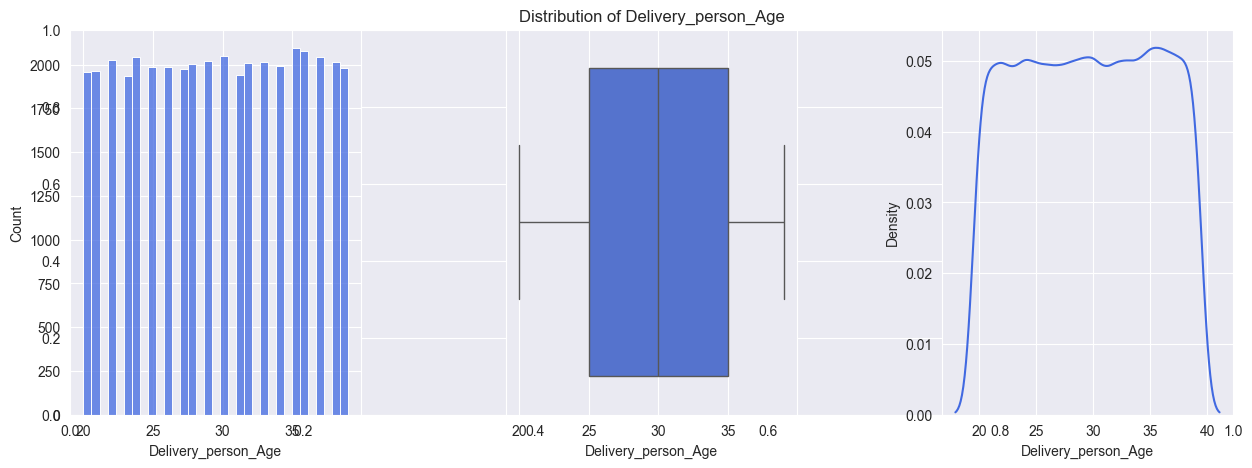

In [79]:
plt.figure(figsize=(15,5))
plt.title("Distribution of Delivery_person_Age")

plt.subplot(1,3,1)
sns.histplot(data['Delivery_person_Age'],color="royalblue")

plt.subplot(1,3,2)
sns.boxplot(x=data['Delivery_person_Age'],color="royalblue")

plt.subplot(1,3,3)
sns.distplot(data['Delivery_person_Age'], hist=False,color="royalblue")

plt.subplots_adjust(wspace=0.5,hspace=0)
plt.show()

<h4 style="text-align: start; color:red; text-transform: uppercase;">
   What is the distribution of delivery time?
   Are there outliers in delivery time?
</h4>

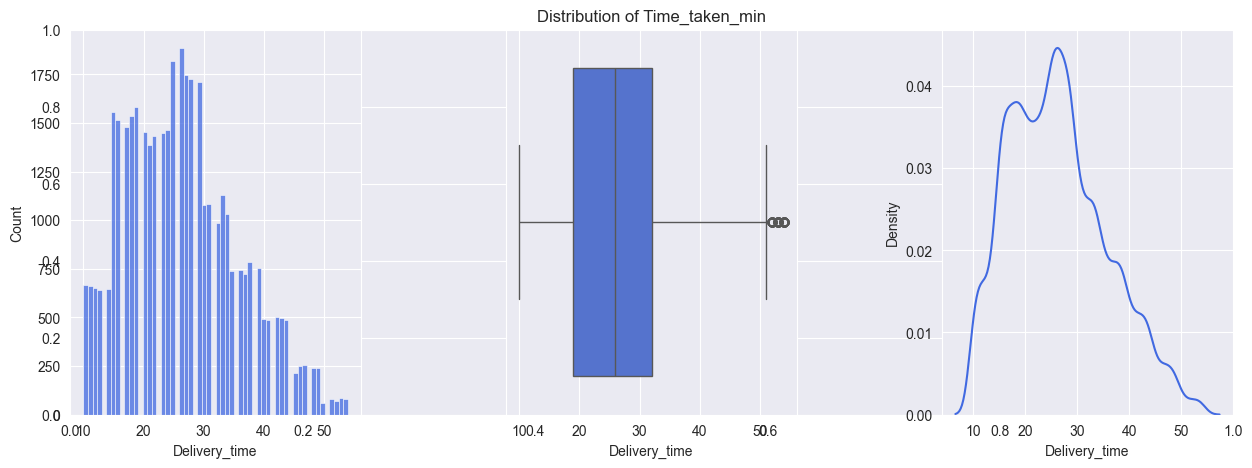

In [80]:
plt.figure(figsize=(15,5))
plt.title("Distribution of Time_taken_min")
plt.subplot(1,3,1)
sns.histplot(data['Delivery_time'],color="royalblue")

plt.subplot(1,3,2)
sns.boxplot(x=data['Delivery_time'],color="royalblue")

plt.subplot(1,3,3)
sns.distplot(data['Delivery_time'], hist=False,color="royalblue")

plt.subplots_adjust(wspace=0.5,hspace=0)
plt.show()


<h4 style="text-align: start; color:red; text-transform: uppercase;">
 Does traffic density affect delivery time?
</h4>

<Axes: title={'center': 'Traffic Density on Delivery Time'}, xlabel='Road_traffic_density', ylabel='Delivery_time'>

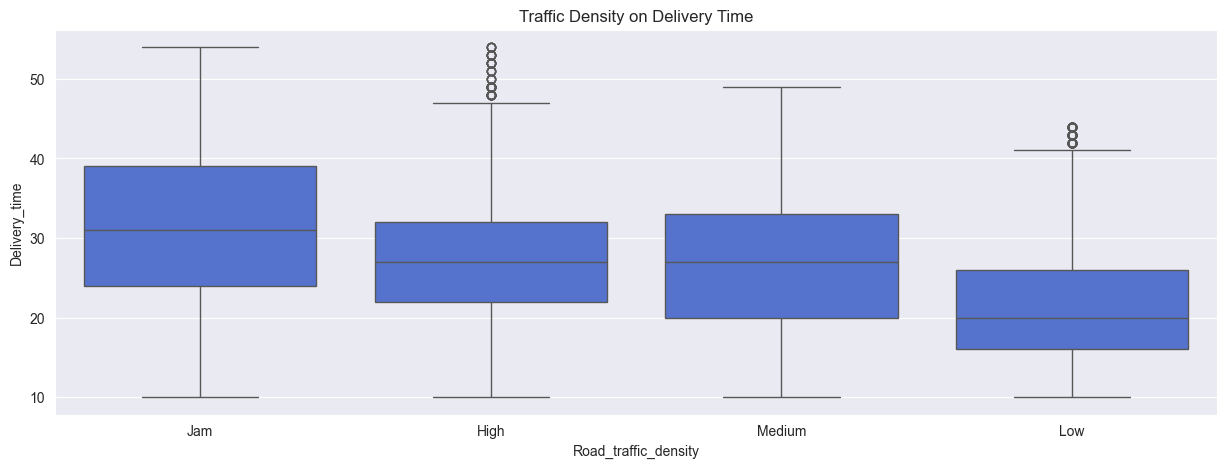

In [81]:
plt.figure(figsize=(15,5))
plt.title("Traffic Density on Delivery Time")
sns.boxplot(data=data, x='Road_traffic_density', y='Delivery_time',color="royalblue")

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Are delivery times higher during peak ordering hours?
</h4>

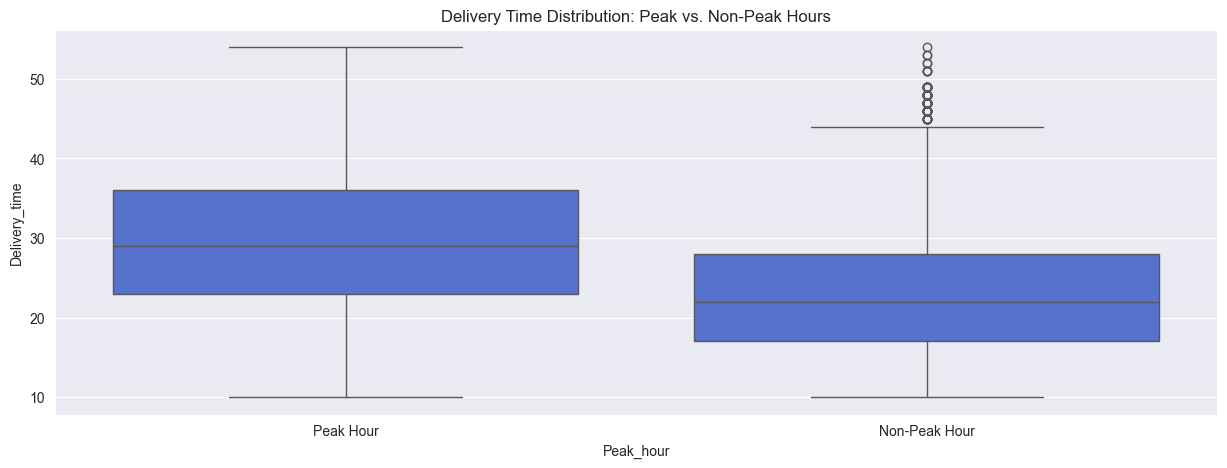

In [82]:
plt.figure(figsize=(15,5))
plt.title("Delivery Time Distribution: Peak vs. Non-Peak Hours")
sns.boxplot( x='Peak_hour',y='Delivery_time',data=data,color="royalblue")
plt.show()

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Does weather affect delivery duration?
</h4>

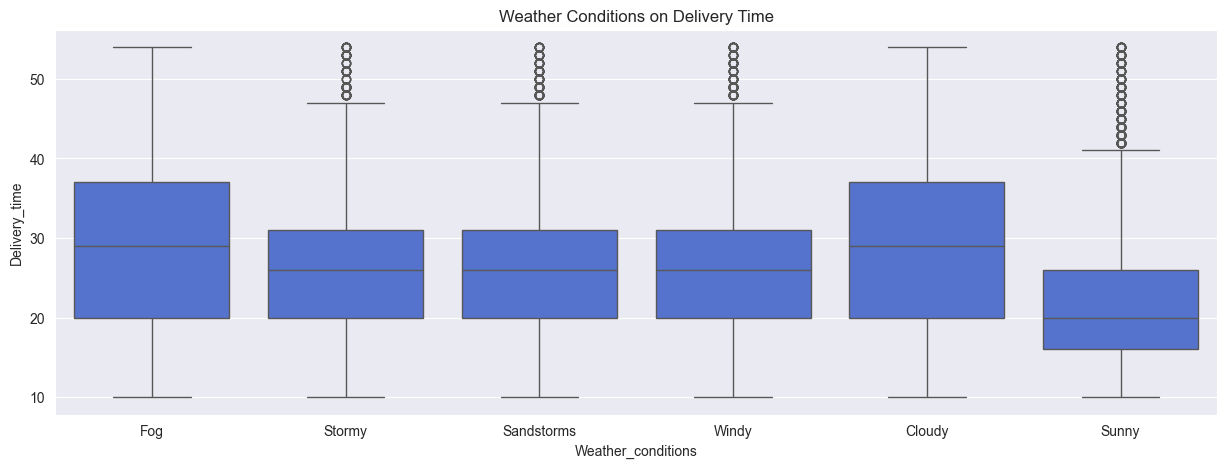

In [83]:
plt.figure(figsize=(15,5))
plt.title("Weather Conditions on Delivery Time")
sns.boxplot(data=data, x='Weather_conditions', y='Delivery_time', color="royalblue")
plt.show()

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Does delivery distance increase delivery time?
</h4>

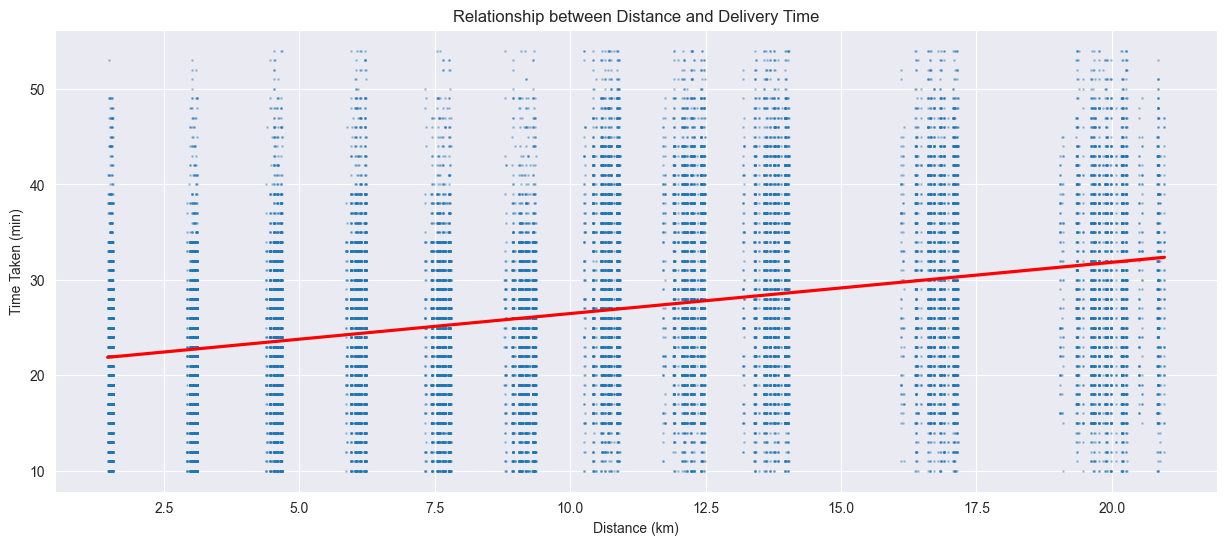

In [84]:
plt.figure(figsize=(15, 6))
plt.title("Relationship between Distance and Delivery Time")

# Using regplot to see the trend line
sns.regplot(data=data[data['Distance'] > 0], x='Distance', y='Delivery_time', 
            scatter_kws={'alpha': 0.3, 's': 1}, 
            line_kws={'color': 'red'})

plt.xlabel("Distance (km)")
plt.ylabel("Time Taken (min)")
plt.show()

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Does preparation time affect delivery duration?
</h4>

In [85]:
data[['Prepration_minute']].head()

,Prepration_minute
0,15
1,10
2,10
3,10
4,15


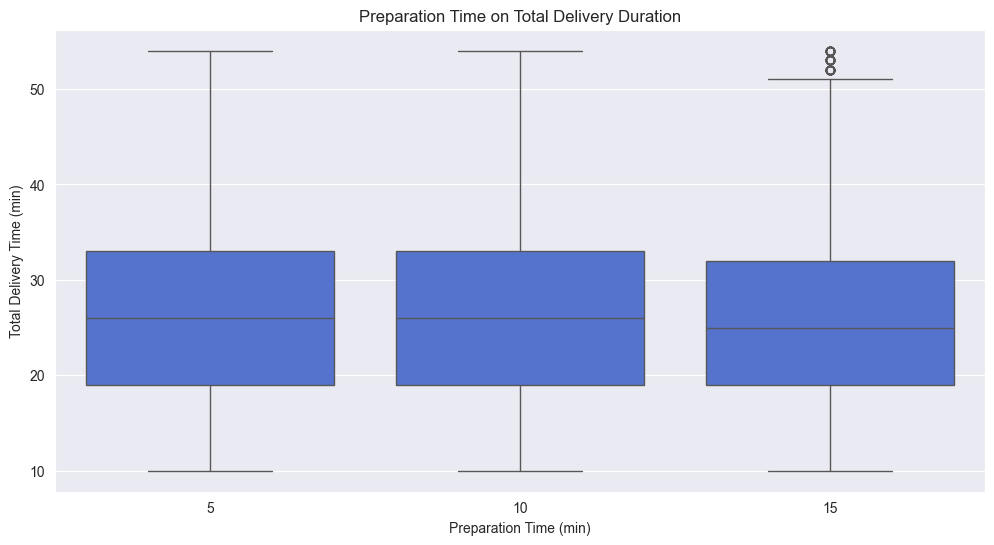

In [86]:
plt.figure(figsize=(12, 6))
plt.title("Preparation Time on Total Delivery Duration")
sns.boxplot(data=data, x='Prepration_minute', y='Delivery_time', color="royalblue")
plt.xlabel("Preparation Time (min)")
plt.ylabel("Total Delivery Time (min)")
plt.show()

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Which vehicle type performs fastest?
</h4>

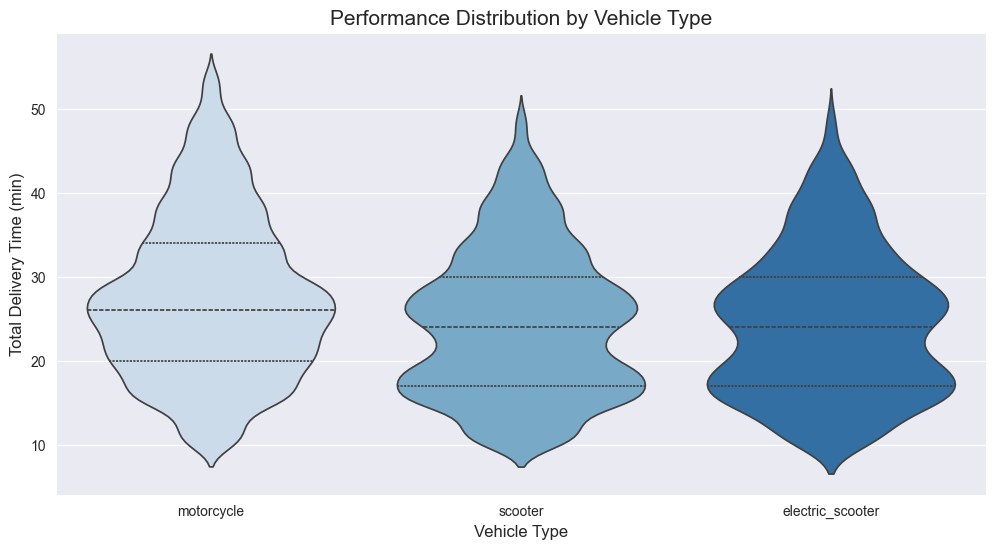

In [87]:
plt.figure(figsize=(12, 6))
plt.title("Performance Distribution by Vehicle Type", fontsize=15)
sns.violinplot(data=data, x='Type_of_vehicle', y='Delivery_time', palette="Blues", inner="quartile")
plt.xlabel("Vehicle Type", fontsize=12)
plt.ylabel("Total Delivery Time (min)", fontsize=12)
plt.show()

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Does handling multiple deliveries increase delay?
</h4>

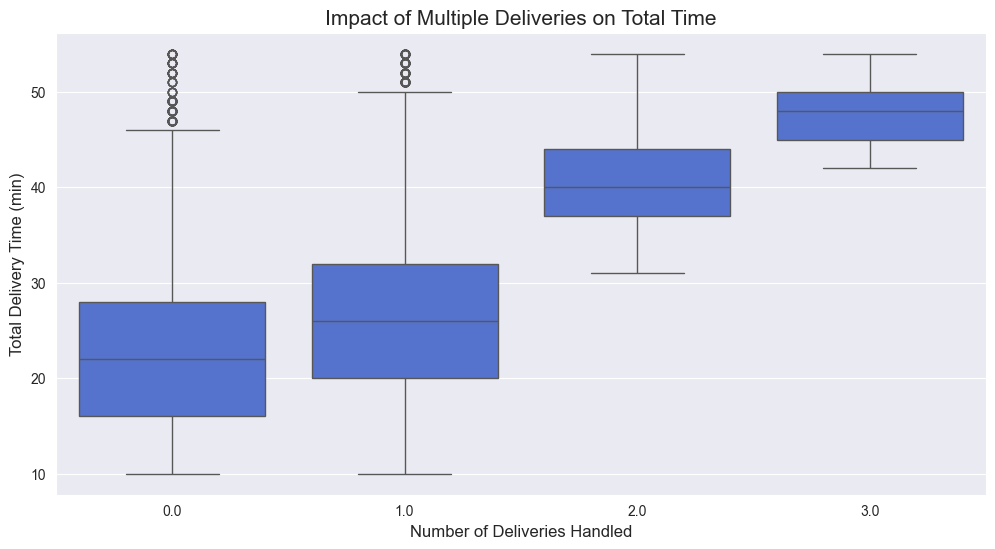

In [88]:
plt.figure(figsize=(12, 6))
plt.title("Impact of Multiple Deliveries on Total Time", fontsize=15)
sns.boxplot(data=data, x='Multiple_deliveries', y='Delivery_time', color="royalblue")
plt.xlabel("Number of Deliveries Handled", fontsize=12)
plt.ylabel("Total Delivery Time (min)", fontsize=12)
plt.show()

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Are festival deliveries slower?
</h4>

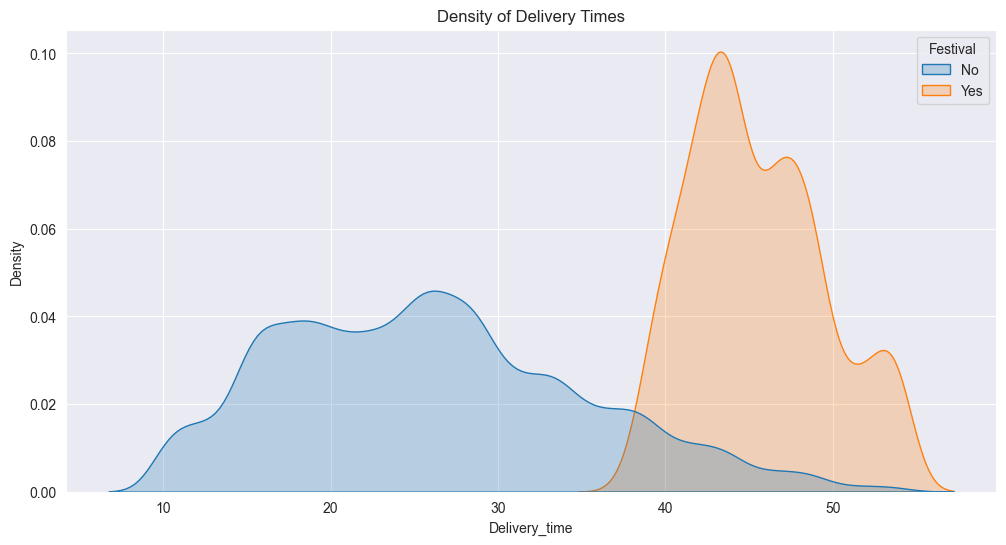

In [89]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=data, x='Delivery_time', hue='Festival', fill=True, common_norm=False)
plt.title("Density of Delivery Times")
plt.show()

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Which time slot has highest delivery time?
</h4>

Text(0, 0.5, 'Avg Delivery Time (min)')

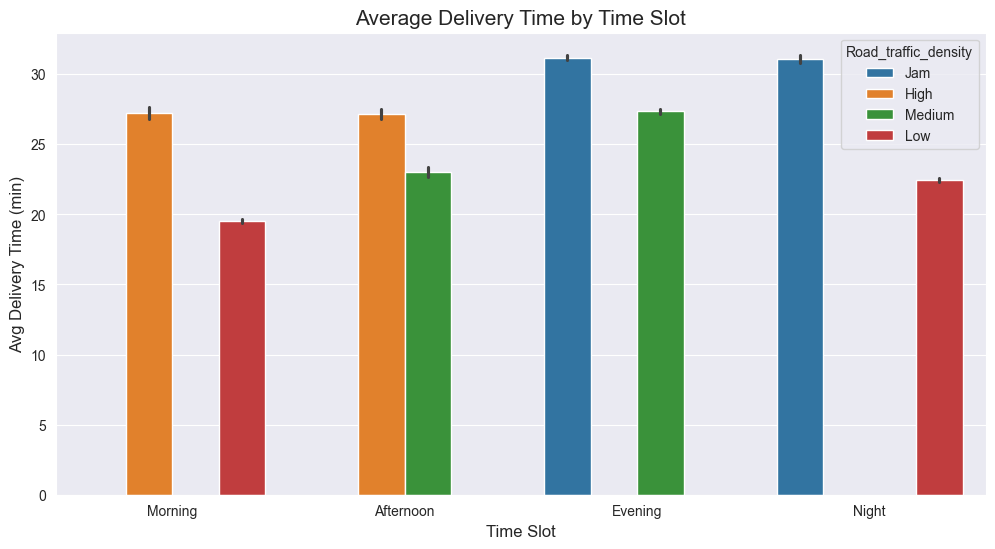

In [90]:
plt.figure(figsize=(12, 6))
plt.title("Average Delivery Time by Time Slot", fontsize=15)
sns.barplot(data=data, x='Time_slot', y='Delivery_time', hue='Road_traffic_density', 
            order=['Morning', 'Afternoon', 'Evening', 'Night'])
plt.xlabel("Time Slot", fontsize=12)
plt.ylabel("Avg Delivery Time (min)", fontsize=12)

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Which city has highest average delivery time?
</h4>

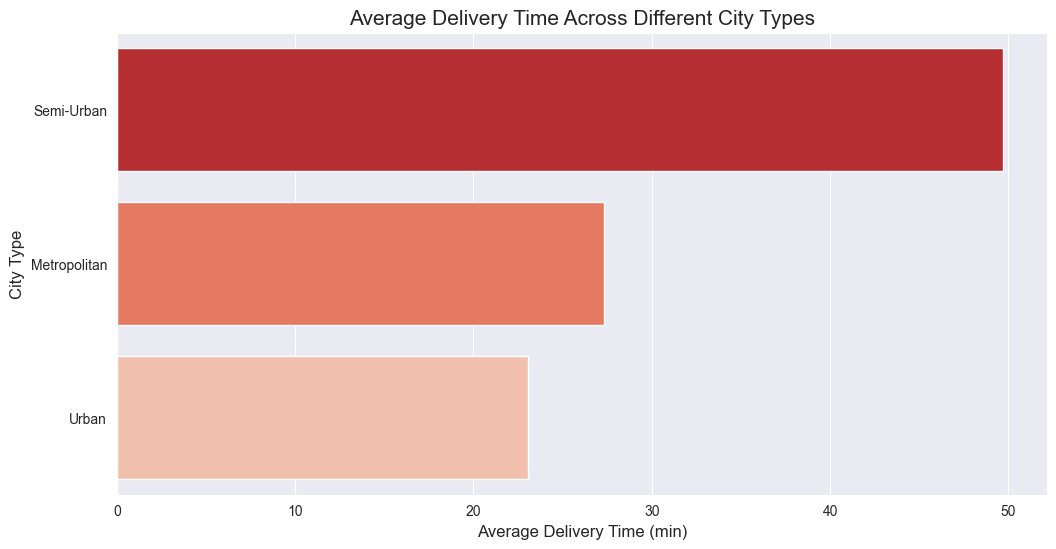

In [91]:
avg_time = data.groupby('City')['Delivery_time'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.title("Average Delivery Time Across Different City Types", fontsize=15)
plt.xlabel("Average Delivery Time (min)", fontsize=12)
plt.ylabel("City Type", fontsize=12)
sns.barplot(x=avg_time.values, y=avg_time.index, palette='Reds_r')
plt.show()

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Which features are most correlated with delivery time?
</h4>

In [92]:
data.select_dtypes(exclude='object').columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Ordered',
       'Time_Order_picked', 'Vehicle_condition', 'Multiple_deliveries',
       'Delivery_time', 'Distance', 'Prepration_minute', 'Is_Weekend'],
      dtype='object')

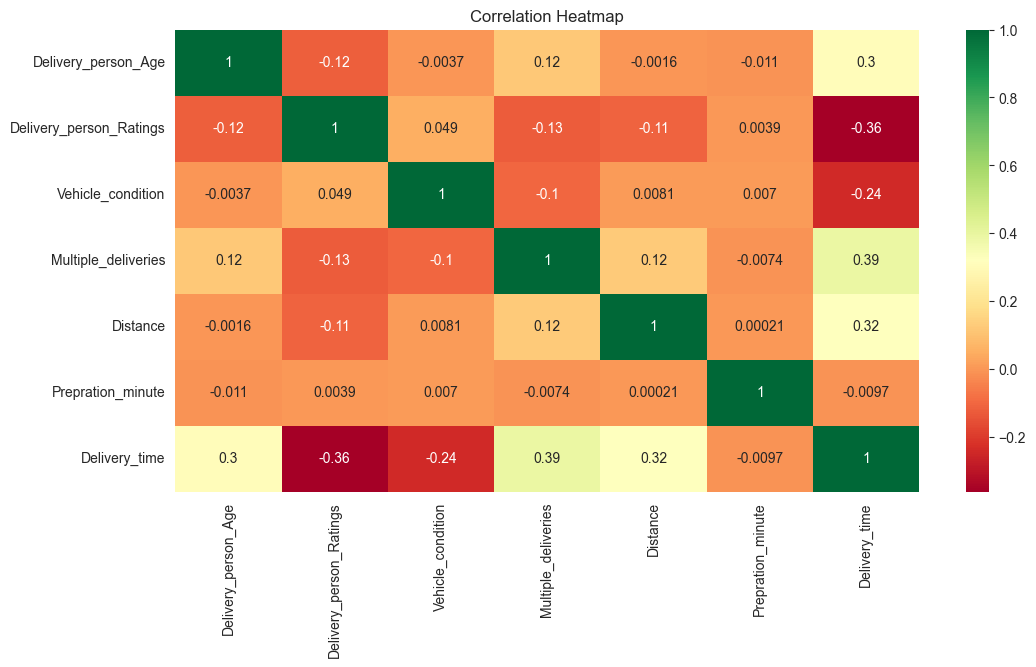

In [93]:
columns = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition', 
        'Multiple_deliveries', 'Distance', 'Prepration_minute', 'Delivery_time']
plt.figure(figsize=(12, 6))
sns.heatmap(data[columns].corr(), annot=True, cmap='RdYlGn')
plt.title('Correlation Heatmap')
plt.show()

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Which combination of weather and traffic creates highest delays?
</h4>

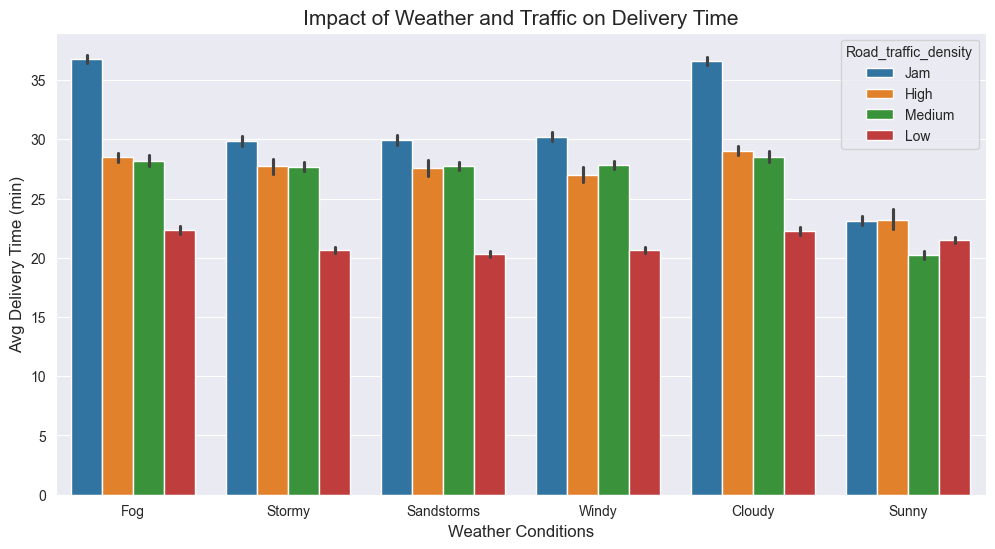

In [94]:
plt.figure(figsize=(12, 6))
plt.title("Impact of Weather and Traffic on Delivery Time", fontsize=15)
sns.barplot(data=data, x='Weather_conditions', y='Delivery_time', hue='Road_traffic_density')
plt.xlabel("Weather Conditions", fontsize=12) 
plt.ylabel("Avg Delivery Time (min)", fontsize=12)
plt.show()

<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
  Train-Test Split
</h2>

In [95]:
from sklearn.model_selection import train_test_split

<h4 style="text-align: start; color:red; text-transform: uppercase;">
drop
</h4>

In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40100 entries, 0 to 40099
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           40100 non-null  object        
 1   Delivery_person_ID           40100 non-null  object        
 2   Delivery_person_Age          40100 non-null  int64         
 3   Delivery_person_Ratings      40100 non-null  float64       
 4   Restaurant_latitude          40100 non-null  float64       
 5   Restaurant_longitude         40100 non-null  float64       
 6   Delivery_location_latitude   40100 non-null  float64       
 7   Delivery_location_longitude  40100 non-null  float64       
 8   Order_Date                   40100 non-null  datetime64[ns]
 9   Time_Ordered                 40100 non-null  datetime64[ns]
 10  Time_Order_picked            40100 non-null  datetime64[ns]
 11  Weather_conditions           40100 non-nu

In [97]:
data['Type_of_vehicle'].value_counts()

Type_of_vehicle
motorcycle          23524
scooter             13386
electric_scooter     3190
Name: count, dtype: int64

In [98]:
X = data.drop(
    columns = ["ID","Delivery_person_ID","Restaurant_latitude","Restaurant_longitude","Delivery_location_latitude","Delivery_location_longitude",
               "Order_Date","Time_Ordered","Time_Order_picked","Delivery_time","Type_of_order","Vehicle_condition"
    ]
)
Y = data['Delivery_time']

In [99]:
X.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weather_conditions',
       'Road_traffic_density', 'Type_of_vehicle', 'Multiple_deliveries',
       'Festival', 'City', 'Distance', 'Time_slot', 'Peak_hour',
       'Prepration_minute', 'Is_Weekend'],
      dtype='object')

In [100]:
Y.head(1)

0    46
Name: Delivery_time, dtype: int64

In [101]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,random_state = 42 , test_size = 0.2)

In [102]:
x_train.shape,y_train.shape

((32080, 13), (32080,))

In [103]:
x_test.shape,y_test.shape

((8020, 13), (8020,))

<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
  Missing Value Handling
</h2>

In [104]:
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

In [105]:
x_train.isna().sum()

Delivery_person_Age          0
Delivery_person_Ratings      0
Weather_conditions           0
Road_traffic_density         0
Type_of_vehicle              0
Multiple_deliveries        664
Festival                   156
City                       832
Distance                     0
Time_slot                    0
Peak_hour                    0
Prepration_minute            0
Is_Weekend                   0
dtype: int64

In [106]:
 x_test.isna().sum()

Delivery_person_Age          0
Delivery_person_Ratings      0
Weather_conditions           0
Road_traffic_density         0
Type_of_vehicle              0
Multiple_deliveries        182
Festival                    48
City                       218
Distance                     0
Time_slot                    0
Peak_hour                    0
Prepration_minute            0
Is_Weekend                   0
dtype: int64

In [107]:
y_train.isna().sum()

np.int64(0)

In [108]:
y_test.isna().sum()

np.int64(0)

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Multiple_deliveries
</h4>

In [109]:
data['Multiple_deliveries'].unique()

array([ 3.,  1.,  0., nan,  2.])

In [110]:
imputer = KNNImputer(n_neighbors=5)

In [111]:
x_train['Multiple_deliveries'] = imputer.fit_transform(x_train[['Multiple_deliveries']]).astype(int)

In [112]:
x_test['Multiple_deliveries'] = imputer.transform(x_test[['Multiple_deliveries']]).astype(int)

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Festival and City
</h4>

In [113]:
data['Festival'].unique()

array(['No', 'Yes', nan], dtype=object)

In [114]:
data['City'].unique()

array(['Metropolitan', 'Urban', nan, 'Semi-Urban'], dtype=object)

In [115]:
cat_cols = ['Festival','City']

In [116]:
imp_mod = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

In [117]:
x_train[cat_cols] = imp_mod.fit_transform(x_train[cat_cols])

In [118]:
x_test[cat_cols] = imp_mod.transform(x_test[cat_cols])

In [119]:
x_train.isna().sum()

Delivery_person_Age        0
Delivery_person_Ratings    0
Weather_conditions         0
Road_traffic_density       0
Type_of_vehicle            0
Multiple_deliveries        0
Festival                   0
City                       0
Distance                   0
Time_slot                  0
Peak_hour                  0
Prepration_minute          0
Is_Weekend                 0
dtype: int64

In [120]:
x_test.isna().sum()

Delivery_person_Age        0
Delivery_person_Ratings    0
Weather_conditions         0
Road_traffic_density       0
Type_of_vehicle            0
Multiple_deliveries        0
Festival                   0
City                       0
Distance                   0
Time_slot                  0
Peak_hour                  0
Prepration_minute          0
Is_Weekend                 0
dtype: int64

<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
  Outlier Handling
</h2>

In [121]:
num_colms =  x_train.select_dtypes(exclude='object').columns
num_colms

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Multiple_deliveries',
       'Distance', 'Prepration_minute', 'Is_Weekend'],
      dtype='object')

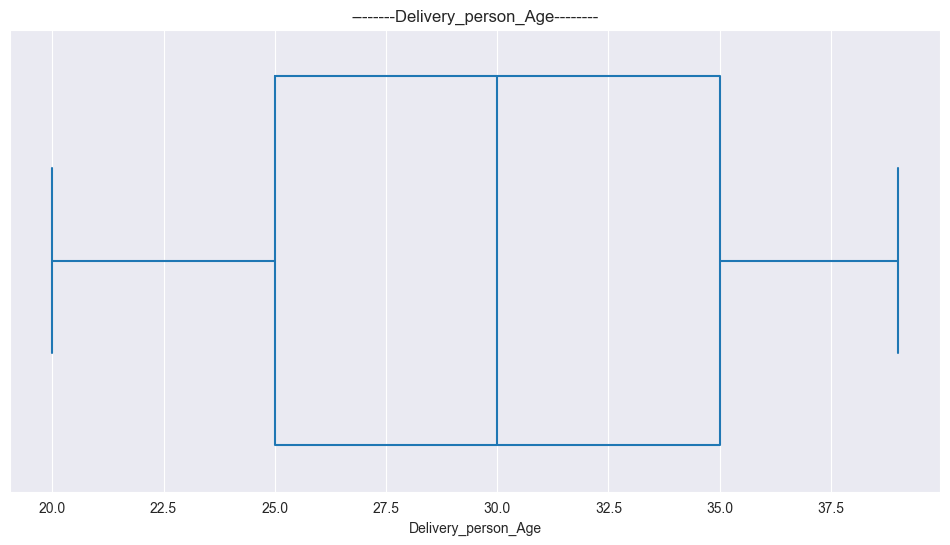

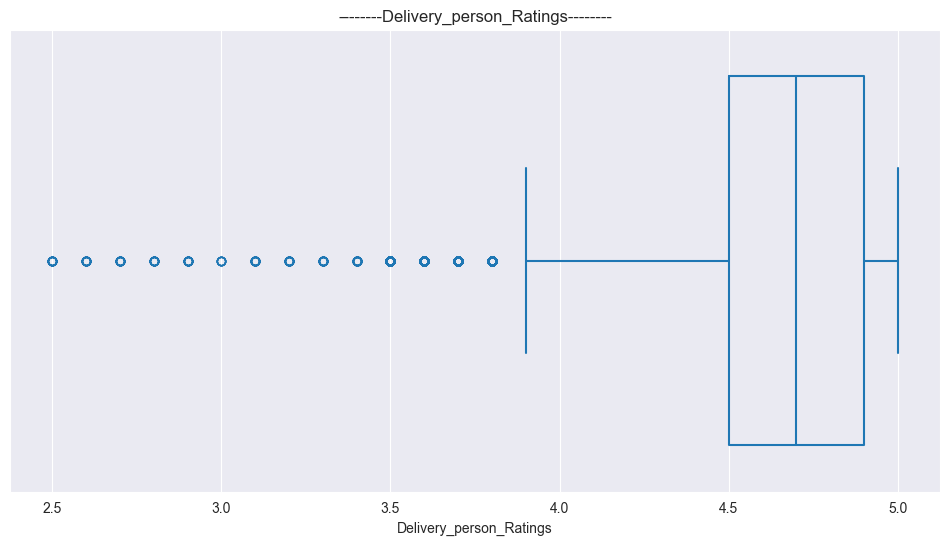

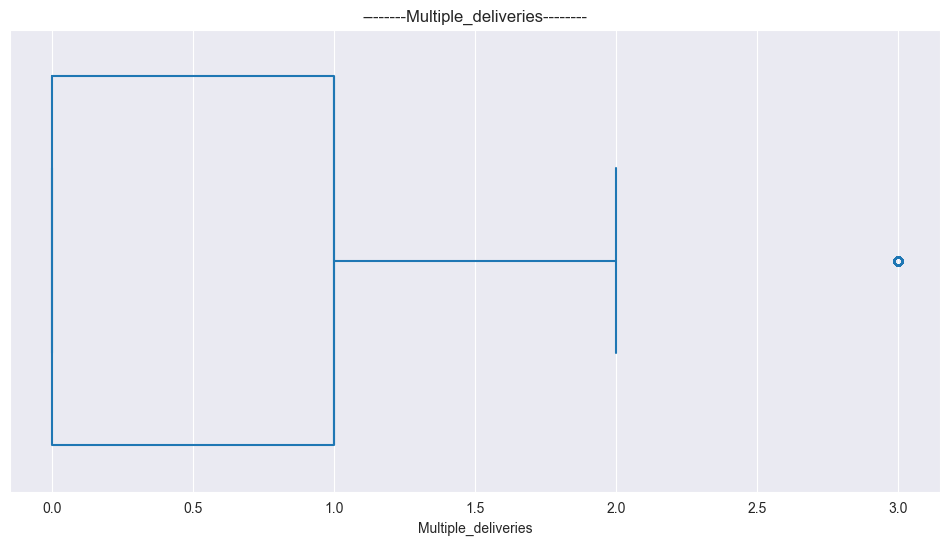

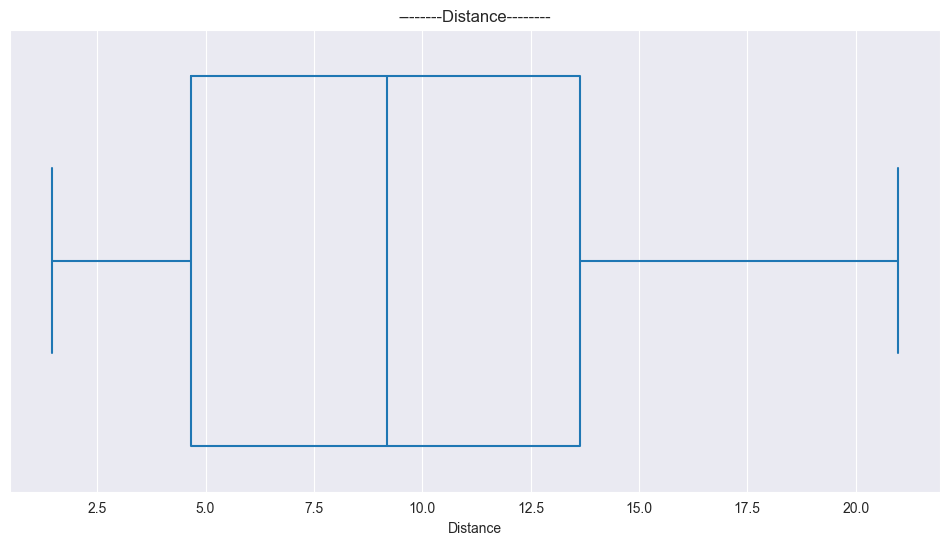

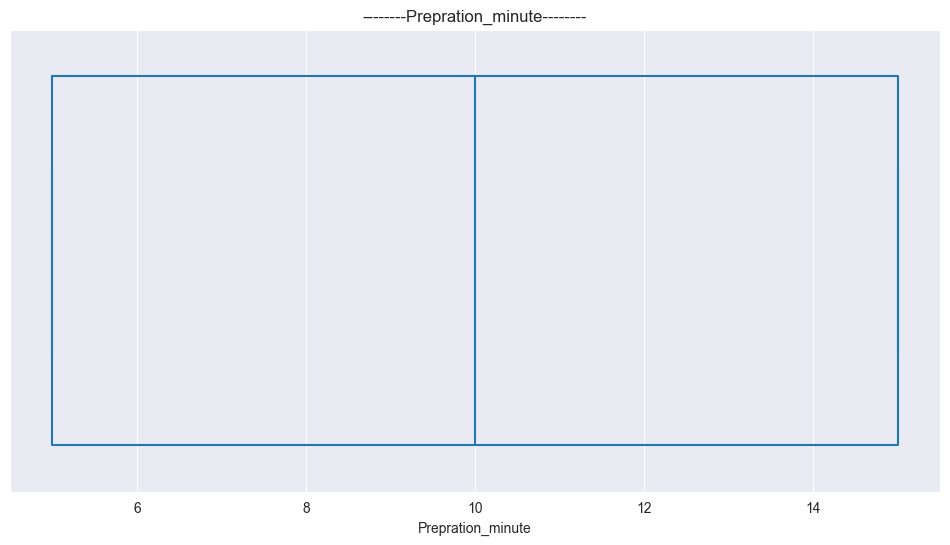

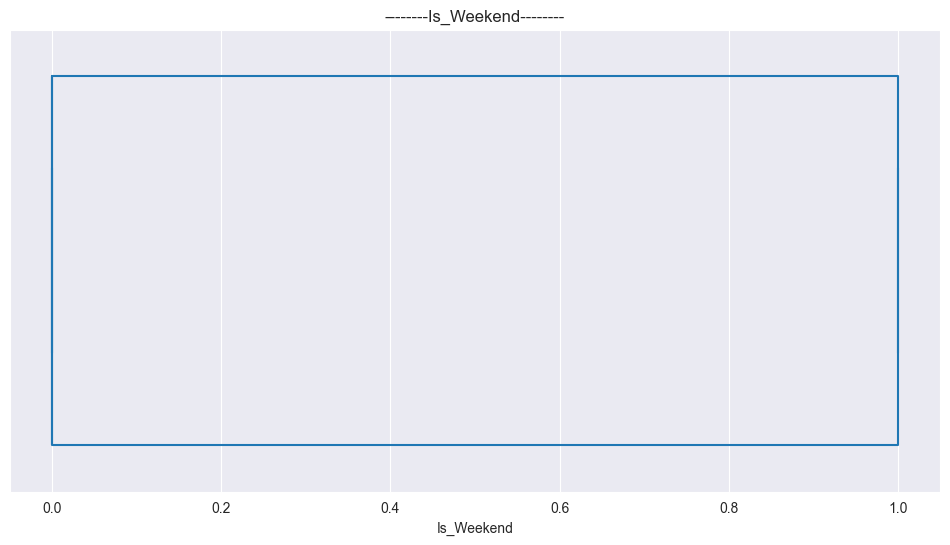

In [122]:
for col in x_train.select_dtypes(exclude='object').columns:
    plt.figure(figsize=(12, 6))
    plt.title(f"--------{col}--------")
    sns.boxplot(x=data[col],fill=False)
    plt.show()

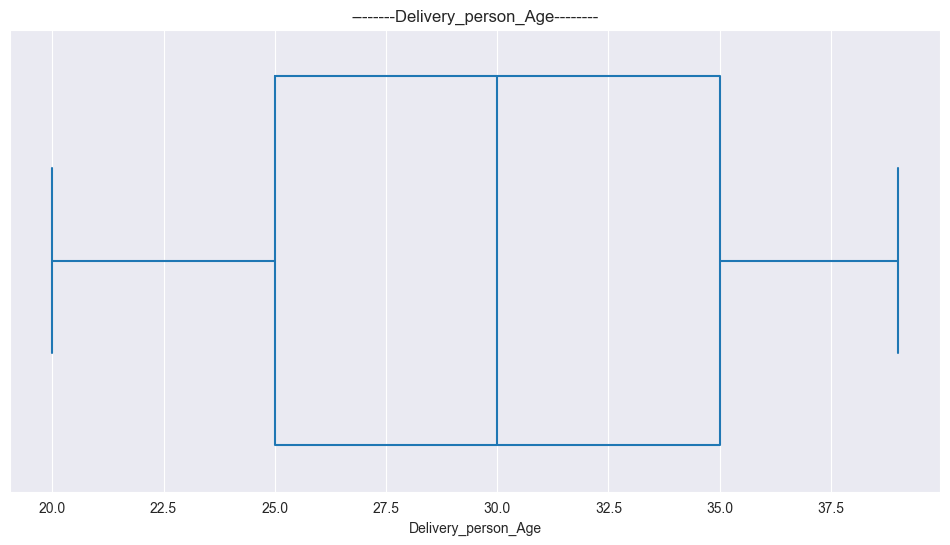

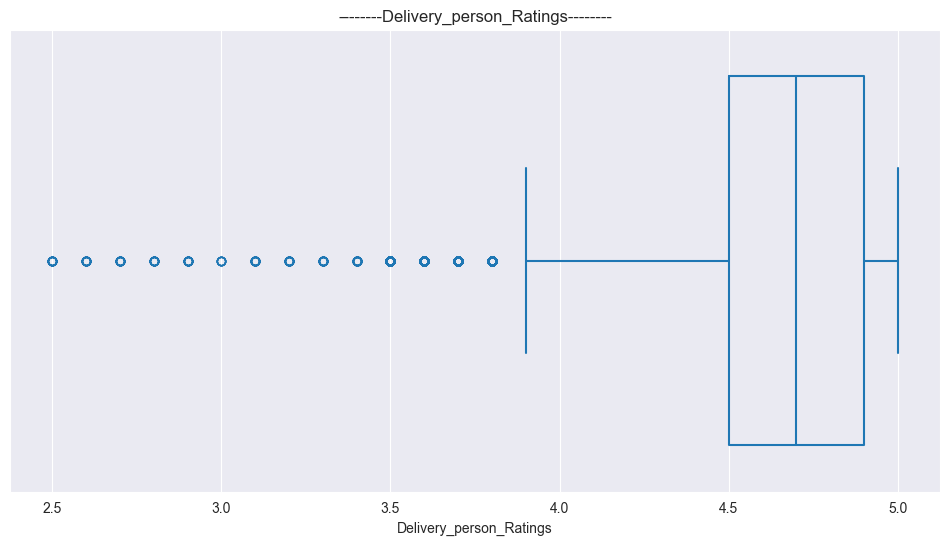

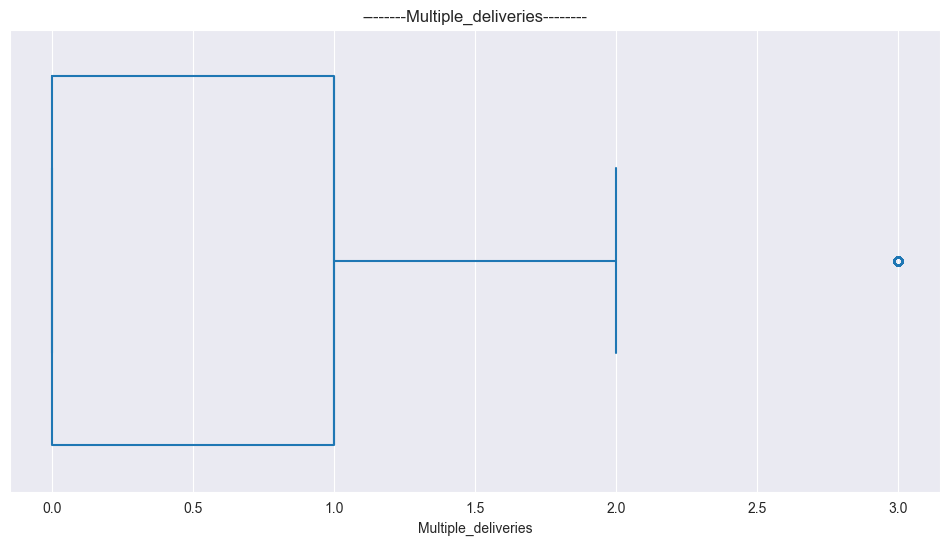

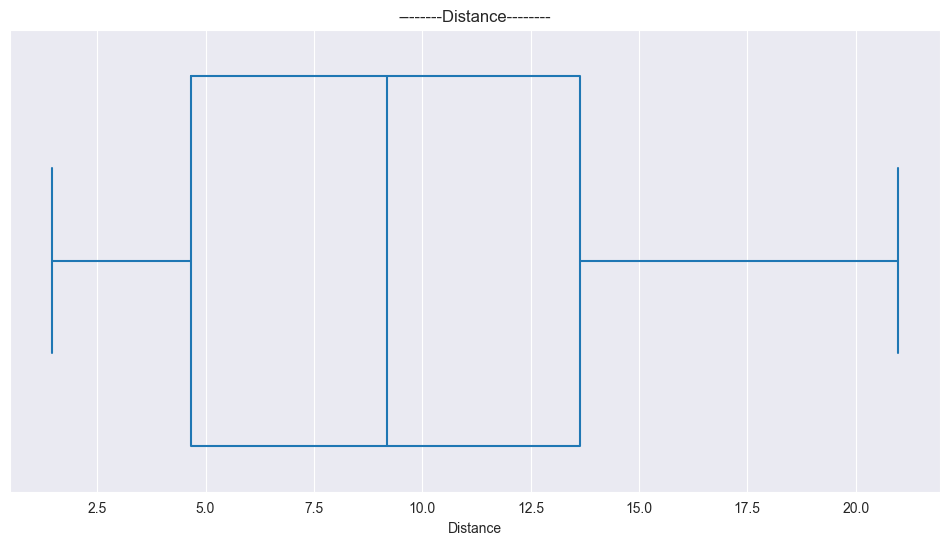

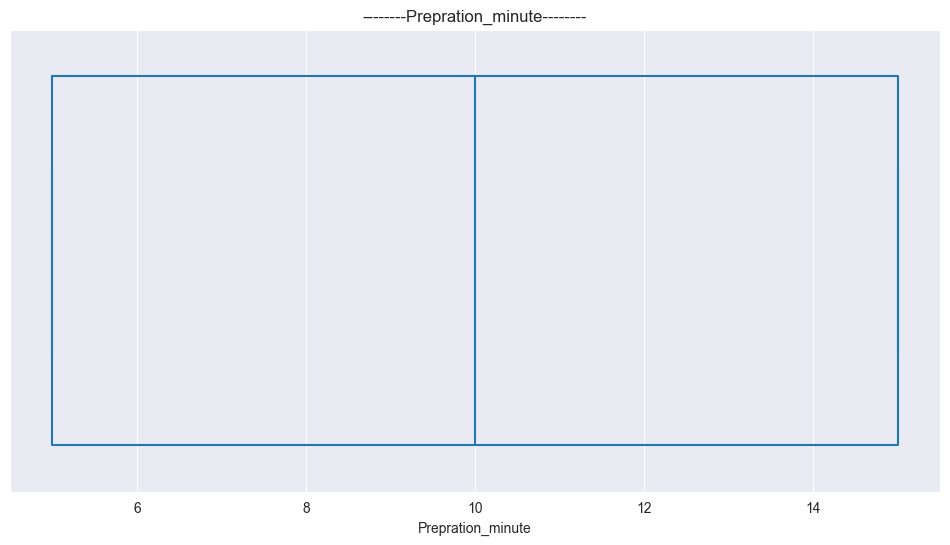

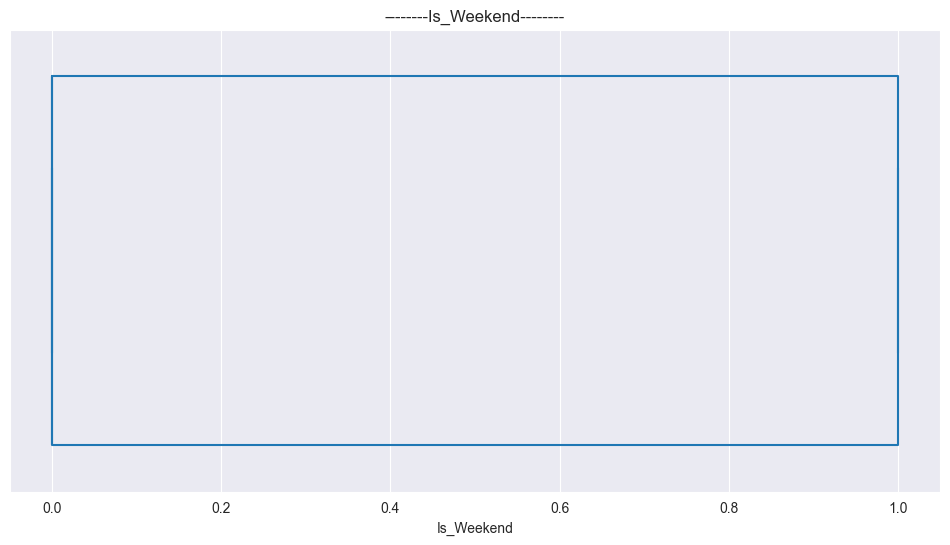

In [123]:
for col in x_test.select_dtypes(exclude='object').columns:
    plt.figure(figsize=(12, 6))
    plt.title(f"--------{col}--------")
    sns.boxplot(x=data[col],fill=False)
    plt.show()

<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
  Encoding
</h2>

In [124]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder

In [125]:
oh_encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

In [126]:
for col in x_train.select_dtypes(include='object'):
    print(f"-----------{col}----------")
    print(x_train[col].unique())

-----------Weather_conditions----------
['Sandstorms' 'Stormy' 'Fog' 'Windy' 'Cloudy' 'Sunny']
-----------Road_traffic_density----------
['Medium' 'Low' 'Jam' 'High']
-----------Type_of_vehicle----------
['scooter' 'motorcycle' 'electric_scooter']
-----------Festival----------
['No' 'Yes']
-----------City----------
['Metropolitan' 'Urban' 'Semi-Urban']
-----------Time_slot----------
['Evening' 'Morning' 'Night' 'Afternoon']
-----------Peak_hour----------
['Non-Peak Hour' 'Peak Hour']


<h4 style="text-align: start; color:red; text-transform: uppercase;">
Festival
</h4>

In [127]:
x_train['Festival'] = x_train['Festival'].map(
    {
        'Yes':1,
        'No':0
    }
)
x_test['Festival'] = x_test['Festival'].map(
    {
        'Yes':1,
        'No':0
    }
)

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Peak_hour
</h4>

In [128]:
x_train['Peak_hour'] = x_train['Peak_hour'].map(
    {
        'Peak Hour':1,
        'Non-Peak Hour':0
    }
)
x_test['Peak_hour'] = x_test['Peak_hour'].map(
    {
        'Peak Hour':1,
        'Non-Peak Hour':0
    }
)

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Weather_conditions
</h4>

In [129]:
x_train = pd.concat(
    [
        x_train.drop(columns=['Weather_conditions']),
        pd.DataFrame(
            data = oh_encoder.fit_transform(x_train[['Weather_conditions']]).astype(int),
            columns = oh_encoder.get_feature_names_out(['Weather_conditions']),
            index = x_train.index
        )
    ],axis=1
)
x_test = pd.concat(
    [
        x_test.drop(columns=['Weather_conditions']),
        pd.DataFrame(
            data = oh_encoder.transform(x_test[['Weather_conditions']]).astype(int),
            columns = oh_encoder.get_feature_names_out(['Weather_conditions']),
            index = x_test.index
        )
    ],axis=1
)

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Road_traffic_density
</h4>

In [130]:
traffic_order = OrdinalEncoder(
    categories=[['Low','Medium','High','Jam']],
    unknown_value=-1,
    handle_unknown='use_encoded_value'
)

x_train['Road_traffic_density'] = traffic_order.fit_transform(x_train[['Road_traffic_density']]).astype(int)
x_test['Road_traffic_density'] = traffic_order.transform(x_test[['Road_traffic_density']]).astype(int)


<h4 style="text-align: start; color:red; text-transform: uppercase;">
Type_of_vehicle
</h4>

In [131]:
x_train = pd.concat(
    [
        x_train.drop(columns=['Type_of_vehicle']),
        pd.DataFrame(
            data = oh_encoder.fit_transform(x_train[['Type_of_vehicle']]).astype(int),
            columns = oh_encoder.get_feature_names_out(['Type_of_vehicle']),
            index = x_train.index
        )
    ],axis=1
)
x_test = pd.concat(
    [
        x_test.drop(columns=['Type_of_vehicle']),
        pd.DataFrame(
            data = oh_encoder.transform(x_test[['Type_of_vehicle']]).astype(int),
            columns = oh_encoder.get_feature_names_out(['Type_of_vehicle']),
            index = x_test.index
        )
    ],axis=1
)

<h4 style="text-align: start; color:red; text-transform: uppercase;">
City
</h4>

In [132]:
city_order = OrdinalEncoder(
    categories=[['Semi-Urban','Urban','Metropolitan']],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
x_train['City'] = city_order.fit_transform(x_train[['City']]).astype(int)
x_test['City'] = city_order.transform(x_test[['City']]).astype(int)

<h4 style="text-align: start; color:red; text-transform: uppercase;">
Time_slot
</h4>

In [133]:
time_order = OrdinalEncoder(
    categories=[[ 'Morning','Afternoon','Evening','Night' ]],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
x_train['Time_slot'] = time_order.fit_transform(x_train[['Time_slot']]).astype(int)
x_test['Time_slot'] = time_order.transform(x_test[['Time_slot']]).astype(int)

In [134]:
for col in x_test:
    print(f"-----------{col}----------")
    print(x_train[col].unique())

-----------Delivery_person_Age----------
[39 27 28 26 32 37 21 25 29 23 36 24 20 35 22 33 38 30 34 31]
-----------Delivery_person_Ratings----------
[4.7 4.1 4.5 4.8 3.9 4.6 4.9 5.  4.2 4.3 3.5 2.6 4.4 4.  3.8 3.7 2.7 3.6
 3.2 2.5 3.4 3.1 3.3 2.8 2.9 3. ]
-----------Road_traffic_density----------
[1 0 3 2]
-----------Multiple_deliveries----------
[1 0 2 3]
-----------Festival----------
[0 1]
-----------City----------
[2 1 0]
-----------Distance----------
[7.6497244  9.32682954 1.51257469 ... 7.54997184 6.05407028 2.9304183 ]
-----------Time_slot----------
[2 0 3 1]
-----------Peak_hour----------
[0 1]
-----------Prepration_minute----------
[ 5 15 10]
-----------Is_Weekend----------
[0 1]
-----------Weather_conditions_Fog----------
[0 1]
-----------Weather_conditions_Sandstorms----------
[1 0]
-----------Weather_conditions_Stormy----------
[0 1]
-----------Weather_conditions_Sunny----------
[0 1]
-----------Weather_conditions_Windy----------
[0 1]
-----------Type_of_vehicle_motorcycle---

<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
  Scaling
</h2>

In [135]:
from sklearn.preprocessing  import StandardScaler
ss_scalor = StandardScaler()

In [136]:
x_test.head(2)

,Delivery_person_Age,Delivery_person_Ratings,Road_traffic_density,Multiple_deliveries,Festival,City,Distance,Time_slot,Peak_hour,Prepration_minute,Is_Weekend,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
7653,27,4.8,3,1,0,2,13.681492,2,1,10,0,0,0,0,0,1,1,0
34523,30,4.6,1,0,0,2,13.613850,2,1,10,1,0,0,0,1,0,1,0


In [137]:
x_test.head(2)

,Delivery_person_Age,Delivery_person_Ratings,Road_traffic_density,Multiple_deliveries,Festival,City,Distance,Time_slot,Peak_hour,Prepration_minute,Is_Weekend,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
7653,27,4.8,3,1,0,2,13.681492,2,1,10,0,0,0,0,0,1,1,0
34523,30,4.6,1,0,0,2,13.613850,2,1,10,1,0,0,0,1,0,1,0


In [138]:
x_train.shape

(32080, 18)

In [139]:
scale_cols = [
    'Delivery_person_Age',
    'Delivery_person_Ratings',
    'Distance'
]
x_train[scale_cols] = ss_scalor.fit_transform(x_train[scale_cols])
x_test[scale_cols] = ss_scalor.transform(x_test[scale_cols])

In [140]:
x_test.head(2)

,Delivery_person_Age,Delivery_person_Ratings,Road_traffic_density,Multiple_deliveries,Festival,City,Distance,Time_slot,Peak_hour,Prepration_minute,Is_Weekend,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
7653,-0.444671,0.524904,3,1,0,2,0.711472,2,1,10,0,0,0,0,0,1,1,0
34523,0.076249,-0.107734,1,0,0,2,0.699384,2,1,10,1,0,0,0,1,0,1,0


In [141]:
x_test.head(2)

,Delivery_person_Age,Delivery_person_Ratings,Road_traffic_density,Multiple_deliveries,Festival,City,Distance,Time_slot,Peak_hour,Prepration_minute,Is_Weekend,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
7653,-0.444671,0.524904,3,1,0,2,0.711472,2,1,10,0,0,0,0,0,1,1,0
34523,0.076249,-0.107734,1,0,0,2,0.699384,2,1,10,1,0,0,0,1,0,1,0


<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
 Model Building
</h2>

In [142]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

<h4 style="text-align: start; color:red; text-transform: uppercase;">
LinearRegression
</h4>

In [143]:
lr_model = LinearRegression()
lr_model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


<h4 style="text-align: start; color:red; text-transform: uppercase;">
RandomForestRegressor
</h4>

In [144]:
rfr_model = RandomForestRegressor()
rfr_model.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<h4 style="text-align: start; color:red; text-transform: uppercase;">
XGBRegressor
</h4>

In [145]:
xgb_model = XGBRegressor()
xgb_model.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


<h4 style="text-align: start; color:red; text-transform: uppercase;">
KNeighborsRegressor
</h4>

In [146]:
knr_model = KNeighborsRegressor()
knr_model.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


<h4 style="text-align: start; color:red; text-transform: uppercase;">
SVM Regressor (SVR)
</h4>

In [147]:
svr_model = SVR()
svr_model.fit(x_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


<h4 style="text-align: start; color:red; text-transform: uppercase;">
DecisionTreeRegressor
</h4>

In [148]:
dtr_model = DecisionTreeRegressor()
dtr_model.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
Model Evaluation
</h2>

In [149]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [150]:

results = []

def evaluate_model(model,x_train,x_test,y_train,y_test,name):
    
    model.fit(x_train,y_train)
    
    y_train_pred = model.predict(x_train)
    y_test_pred  = model.predict(x_test)

    return{
        "Model":name,
        
        "Train R2":r2_score(y_train,y_train_pred),
        "Test R2": r2_score(y_test,y_test_pred),

        "Train MSE":mean_squared_error(y_train,y_train_pred),
        "Test MSE" : mean_squared_error(y_test,y_test_pred),

        "Train MAE":mean_absolute_error(y_train,y_train_pred),
        "Test MAE": mean_absolute_error(y_test,y_test_pred),

        "Train RMSE":np.sqrt(mean_squared_error(y_train,y_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test,y_test_pred))       
        
    }

In [151]:
results.append(evaluate_model(lr_model,x_train,x_test,y_train,y_test,"LinearRegression"))
results.append(evaluate_model(rfr_model,x_train,x_test,y_train,y_test,"RandomForestRegressor"))
results.append(evaluate_model(xgb_model,x_train,x_test,y_train,y_test,"XGBRegressor "))
results.append(evaluate_model(knr_model,x_train,x_test,y_train,y_test,"KNeighborsRegressor"))
results.append(evaluate_model(svr_model,x_train,x_test,y_train,y_test,"SVM Regressor (SVR) "))
results.append(evaluate_model(dtr_model,x_train,x_test,y_train,y_test,"DecisionTreeRegressor"))

In [152]:
reslt_table  = pd.DataFrame(results)
reslt_table

,Model,Train R2,Test R2,Train MSE,Test MSE,Train MAE,Test MAE,Train RMSE,Test RMSE
0,LinearRegression,0.567223,0.558731,38.097224,38.390390,4.901922,4.913358,6.172295,6.195998
1,RandomForestRegressor,0.967864,0.765153,2.828885,20.431644,1.309813,3.539689,1.681929,4.520138
2,XGBRegressor,0.834174,0.777271,14.597610,19.377428,3.012663,3.479212,3.820682,4.401980
3,KNeighborsRegressor,0.776590,0.649582,19.666706,30.486344,3.424738,4.266334,4.434716,5.521444
4,SVM Regressor (SVR),0.587411,0.582839,36.320066,36.292997,4.740586,4.743137,6.026613,6.024367
5,DecisionTreeRegressor,0.999999,0.572247,0.000078,37.214464,0.000094,4.629925,0.008828,6.100366


<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
Hyperparameter Tuning
</h2>

In [153]:
from sklearn.model_selection import RandomizedSearchCV

<h4 style="text-align: start; color:red; text-transform: uppercase;">
XGBRegressor
</h4>

In [154]:
xgb_model = XGBRegressor(random_state=42)

In [155]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4,5,6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5],
    'gamma': [0, 0.1, 0.3]
}

In [156]:
random_search_xgb = RandomizedSearchCV(
    estimator = xgb_model,
    param_distributions = param_grid,
    scoring='neg_root_mean_squared_error',
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
random_search_xgb.fit(x_train, y_train, eval_set=[(x_test, y_test)],verbose=False)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 5, ...], ...}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [157]:
random_search_xgb.best_params_

{'subsample': 0.7,
 'reg_lambda': 5,
 'reg_alpha': 1,
 'n_estimators': 200,
 'max_depth': 6,
 'learning_rate': 0.1,
 'gamma': 0,
 'colsample_bytree': 0.7}

In [158]:
best_xgb = random_search_xgb.best_estimator_

In [159]:
y_train_pred = best_xgb.predict(x_train)
y_test_pred = best_xgb.predict(x_test)

In [160]:
new_result = []
new_result.append(evaluate_model(best_xgb,x_train,x_test,y_train,y_test,"Tuned XGBoost"))

In [161]:
new_result_table = pd.DataFrame(new_result)
new_result_table

,Model,Train R2,Test R2,Train MSE,Test MSE,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Tuned XGBoost,0.813617,0.780227,16.40719,19.120222,3.206853,3.454851,4.050579,4.372668


<h4 style="text-align: start; color:red; text-transform: uppercase;">
RandomForestRegressor
</h4>

In [162]:
rf_model = RandomForestRegressor(
    random_state=42
)

In [163]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

In [164]:
random_search_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
random_search_rf.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'bootstrap': [True], 'max_depth': [5, 10, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [2, 4, ...], ...}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [165]:
random_search_rf.best_params_

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 15,
 'bootstrap': True}

In [166]:
best_rf = random_search_rf.best_estimator_

In [167]:
new_result.append(evaluate_model(best_rf,x_train,x_test,y_train,y_test,"Tuned Random Forest"))

In [168]:
new_result_table = pd.DataFrame(new_result)
new_result_table

,Model,Train R2,Test R2,Train MSE,Test MSE,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Tuned XGBoost,0.813617,0.780227,16.40719,19.120222,3.206853,3.454851,4.050579,4.372668
1,Tuned Random Forest,0.841514,0.770326,13.95144,19.981667,2.894534,3.509616,3.735163,4.470086


<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
 Feature Importance / Model Interpretation
</h2>

In [169]:
importance_1 = best_xgb.feature_importances_

feature_importance_1 = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': importance_1
}).sort_values(by='Importance', ascending=False)

feature_importance_1

,Feature,Importance
14,Weather_conditions_Sunny,0.143864
3,Multiple_deliveries,0.110639
2,Road_traffic_density,0.104581
8,Peak_hour,0.096380
11,Weather_conditions_Fog,0.095835
4,Festival,0.092313
1,Delivery_person_Ratings,0.088359
0,Delivery_person_Age,0.039881
15,Weather_conditions_Windy,0.036845
13,Weather_conditions_Stormy,0.035853


In [170]:
importance_2 = best_rf.feature_importances_

feature_importance_2 = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': importance_2
}).sort_values(by='Importance', ascending=False)

feature_importance_2

,Feature,Importance
1,Delivery_person_Ratings,0.191166
0,Delivery_person_Age,0.131199
2,Road_traffic_density,0.125556
6,Distance,0.123181
3,Multiple_deliveries,0.104569
14,Weather_conditions_Sunny,0.070435
8,Peak_hour,0.047126
4,Festival,0.040761
11,Weather_conditions_Fog,0.035919
7,Time_slot,0.021734


<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
Final Insights & Business Conclusion
</h2>

<h3 style="text-align: start; color:red; text-transform: uppercase;">
    Key findings
</h3>

<h3 style="text-align: start; color:red; text-transform: uppercase;">
    Business insight
</h3>

<h3 style="text-align: start; color:red; text-transform: uppercase;">
    Recommendations
</h3>

<h3 style="text-align: start; color:red; text-transform: uppercase;">
    Final model selection
</h3>

<h2 style="text-align: start; color: SteelBlue; text-transform: uppercase;">
Deployment
</h2>

In [171]:
import pickle

In [192]:
# pickle.dump(best_xgb, open('model.pkl', 'wb'))
# pickle.dump(ss_scalor, open('scaler.pkl', 'wb'))

In [193]:
# feature_columns = x_train.columns
# pickle.dump(feature_columns, open('features.pkl', 'wb'))

In [184]:
sample = x_test.iloc[65:66].copy()
sample

,Delivery_person_Age,Delivery_person_Ratings,Road_traffic_density,Multiple_deliveries,Festival,City,Distance,Time_slot,Peak_hour,Prepration_minute,Is_Weekend,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
6112,-0.271031,-1.056691,0,0,0,2,-1.178531,0,0,15,0,0,0,0,0,1,1,0


In [185]:
sample_1 = y_test.iloc[65:66].copy()
sample_1

6112    23
Name: Delivery_time, dtype: int64

In [188]:
sample = x_test.iloc[65:66].copy()
sample_scaled = sample.copy()

In [189]:
print(random_search_xgb.predict(sample_scaled).round())

[22.]
